# Customer Churn Prediction

## Project Objective

The objective of this project is to predict customer churn using machine learning techniques and identify the factors that contribute most to customer attrition.

In [71]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## Loading Datasets

The project contains multiple datasets related to customers, business costs, campaign performance, and customer feedback.

In [72]:
customers = pd.read_csv("full_customers.csv")
costs = pd.read_csv("business_costs.csv")
feedback = pd.read_csv("customer_feedback.csv")
campaign = pd.read_csv("campaign_uplift.csv")

In [73]:
print("Customers:", customers.shape)
print("Costs:", costs.shape)
print("Feedback:", feedback.shape)
print("Campaign:", campaign.shape)

Customers: (3333, 34)
Costs: (3333, 8)
Feedback: (3333, 5)
Campaign: (3333, 9)


## Previewing Datasets

The first few rows of each dataset are examined to understand the available information.

In [74]:
customers.head()

,customer_id,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn,split,has_international_plan,has_voice_mail_plan,total_minutes,total_calls,total_charges,avg_charge_per_minute,support_call_rate,high_service_calls,usage_intensity,customer_value_segment,rule_based_churn_risk_score,rule_based_churn_risk_level
0,CUST_000001,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0,train,0,1,717.2,303,75.56,0.105354,0.007812,0,high_usage,high_value,15,low
1,CUST_000002,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0,train,0,1,625.2,332,59.24,0.094754,0.009346,0,medium_usage,medium_value,0,low
2,CUST_000003,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0,train,0,0,539.4,333,62.29,0.115480,0.000000,0,low_usage,medium_value,10,low
3,CUST_000004,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0,train,1,0,564.8,255,66.80,0.118272,0.023810,0,medium_usage,high_value,45,medium
4,CUST_000005,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0,train,1,0,512.0,359,52.09,0.101738,0.040000,0,low_usage,low_value,30,low


In [75]:
costs.head()

,customer_id,monthly_revenue,estimated_remaining_months,estimated_clv,offer_type,retention_cost,expected_loss_if_churn,net_gain_if_retained
0,CUST_000001,75.56,18,1360.08,no_offer,0.0,0.0,1360.08
1,CUST_000002,59.24,12,710.88,no_offer,0.0,0.0,710.88
2,CUST_000003,62.29,12,747.48,no_offer,0.0,0.0,747.48
3,CUST_000004,66.80,18,1202.40,free_international_trial,10.0,0.0,1192.40
4,CUST_000005,52.09,6,312.54,no_offer,0.0,0.0,312.54


In [76]:
feedback.head()

,customer_id,feedback_text,feedback_category,sentiment,complaint_intensity
0,CUST_000001,"I use the service a lot, but the monthly cost ...",pricing,neutral,3
1,CUST_000002,The service works well and I have no major com...,service_quality,positive,1
2,CUST_000003,The service works well and I have no major com...,service_quality,positive,1
3,CUST_000004,The service works well and I have no major com...,service_quality,positive,1
4,CUST_000005,The service works well and I have no major com...,service_quality,positive,1


In [77]:
campaign.head()

,customer_id,treatment_group,campaign_channel,offer_type,contacted,responded,original_churn,churn_after_campaign,uplift_label
0,CUST_000001,control,none,no_offer,0,0,0,0,sure_thing
1,CUST_000002,control,none,no_offer,0,0,0,0,sure_thing
2,CUST_000003,control,none,no_offer,0,0,0,0,sure_thing
3,CUST_000004,treatment,SMS,free_international_trial,1,0,0,0,do_not_disturb
4,CUST_000005,control,none,no_offer,0,0,0,0,sure_thing


## Data Quality Assessment

This step checks data types, missing values, and duplicate records.

In [78]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  3333 non-null   object 
 1   state                        3333 non-null   object 
 2   account_length               3333 non-null   int64  
 3   area_code                    3333 non-null   int64  
 4   international_plan           3333 non-null   object 
 5   voice_mail_plan              3333 non-null   object 
 6   number_vmail_messages        3333 non-null   int64  
 7   total_day_minutes            3333 non-null   float64
 8   total_day_calls              3333 non-null   int64  
 9   total_day_charge             3333 non-null   float64
 10  total_eve_minutes            3333 non-null   float64
 11  total_eve_calls              3333 non-null   int64  
 12  total_eve_charge             3333 non-null   float64
 13  total_night_minute

In [79]:
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 3333 non-null   object 
 1   monthly_revenue             3333 non-null   float64
 2   estimated_remaining_months  3333 non-null   int64  
 3   estimated_clv               3333 non-null   float64
 4   offer_type                  3333 non-null   object 
 5   retention_cost              3333 non-null   float64
 6   expected_loss_if_churn      3333 non-null   float64
 7   net_gain_if_retained        3333 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 208.4+ KB


In [80]:
feedback.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          3333 non-null   object
 1   feedback_text        3333 non-null   object
 2   feedback_category    3333 non-null   object
 3   sentiment            3333 non-null   object
 4   complaint_intensity  3333 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 130.3+ KB


In [81]:
campaign.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   customer_id           3333 non-null   object
 1   treatment_group       3333 non-null   object
 2   campaign_channel      3333 non-null   object
 3   offer_type            3333 non-null   object
 4   contacted             3333 non-null   int64 
 5   responded             3333 non-null   int64 
 6   original_churn        3333 non-null   int64 
 7   churn_after_campaign  3333 non-null   int64 
 8   uplift_label          3333 non-null   object
dtypes: int64(4), object(5)
memory usage: 234.5+ KB


In [82]:
customers.isnull().sum()

customer_id                    0
state                          0
account_length                 0
area_code                      0
international_plan             0
voice_mail_plan                0
number_vmail_messages          0
total_day_minutes              0
total_day_calls                0
total_day_charge               0
total_eve_minutes              0
total_eve_calls                0
total_eve_charge               0
total_night_minutes            0
total_night_calls              0
total_night_charge             0
total_intl_minutes             0
total_intl_calls               0
total_intl_charge              0
customer_service_calls         0
churn                          0
split                          0
has_international_plan         0
has_voice_mail_plan            0
total_minutes                  0
total_calls                    0
total_charges                  0
avg_charge_per_minute          0
support_call_rate              0
high_service_calls             0
usage_inte

In [83]:
costs.isnull().sum()

customer_id                   0
monthly_revenue               0
estimated_remaining_months    0
estimated_clv                 0
offer_type                    0
retention_cost                0
expected_loss_if_churn        0
net_gain_if_retained          0
dtype: int64

In [84]:
feedback.isnull().sum()

customer_id            0
feedback_text          0
feedback_category      0
sentiment              0
complaint_intensity    0
dtype: int64

In [85]:
campaign.isnull().sum()

customer_id             0
treatment_group         0
campaign_channel        0
offer_type              0
contacted               0
responded               0
original_churn          0
churn_after_campaign    0
uplift_label            0
dtype: int64

In [86]:
customers.duplicated().sum()


0

In [87]:
costs.duplicated().sum()

0

In [88]:
feedback.duplicated().sum()

0

In [89]:
campaign.duplicated().sum()

0

## Exploratory Data Analysis

EDA is performed to identify patterns associated with customer churn.

In [90]:
customers['churn'].value_counts()

churn
0    2850
1     483
Name: count, dtype: int64

In [91]:
customers['churn'].value_counts(normalize=True)*100

churn
0    85.508551
1    14.491449
Name: proportion, dtype: float64

### Observation

The dataset is imbalanced, with approximately 85% non-churn customers and 15% churn customers.

### Churn Distribution Visualization

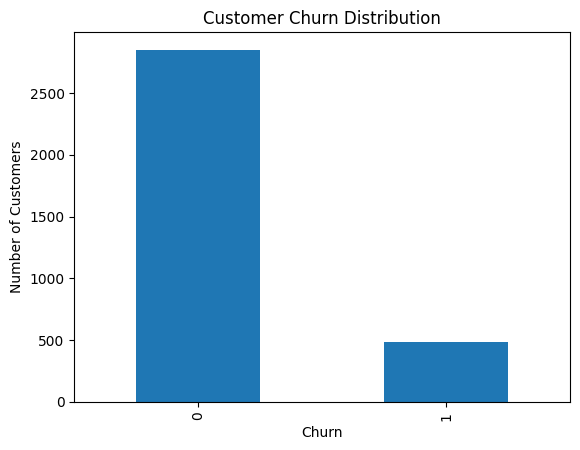

In [92]:
customers['churn'].value_counts().plot(kind='bar')

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [93]:
customers['split'].value_counts()

split
train    2666
test      667
Name: count, dtype: int64

In [94]:
pd.crosstab(
    customers['international_plan'],
    customers['has_international_plan']
)

has_international_plan,0,1
international_plan,,
No,3010,0
Yes,0,323


In [95]:
pd.crosstab(
    customers['voice_mail_plan'],
    customers['has_voice_mail_plan']
)

has_voice_mail_plan,0,1
voice_mail_plan,,
No,2411,0
Yes,0,922


In [96]:
customers.groupby('churn')['customer_service_calls'].mean()

churn
0    1.449825
1    2.229814
Name: customer_service_calls, dtype: float64

### Customer Service Calls vs Churn

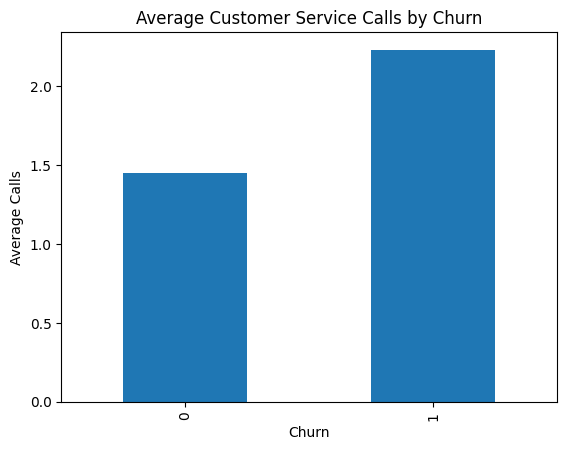

In [97]:
customers.groupby('churn')['customer_service_calls'].mean().plot(kind='bar')

plt.title("Average Customer Service Calls by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Calls")
plt.show()

In [98]:
pd.crosstab(
    customers['customer_value_segment'],
    customers['churn']
)

churn,0,1
customer_value_segment,,
high_value,876,257
low_value,955,145
medium_value,1019,81


In [99]:
pd.crosstab(
    customers['usage_intensity'],
    customers['churn']
)

churn,0,1
usage_intensity,,
high_usage,877,256
low_usage,967,134
medium_usage,1006,93


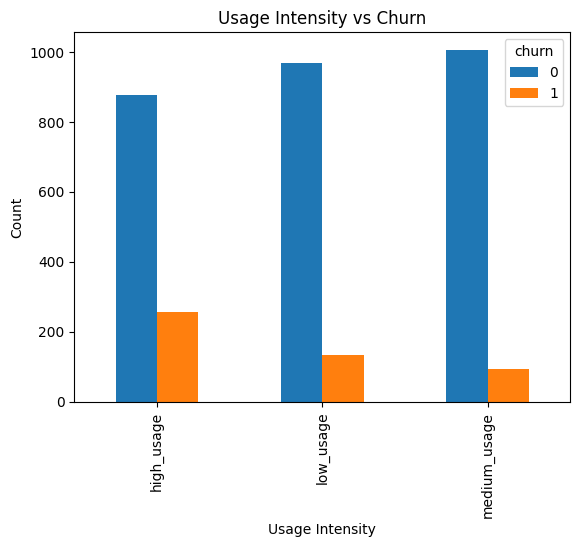

In [100]:
pd.crosstab(
    customers['usage_intensity'],
    customers['churn']
).plot(kind='bar')

plt.title("Usage Intensity vs Churn")
plt.xlabel("Usage Intensity")
plt.ylabel("Count")
plt.show()

In [101]:
customers.groupby('churn')['total_charges'].mean()

churn
0    58.448807
1    65.355963
Name: total_charges, dtype: float64

### Average Charges vs Churn

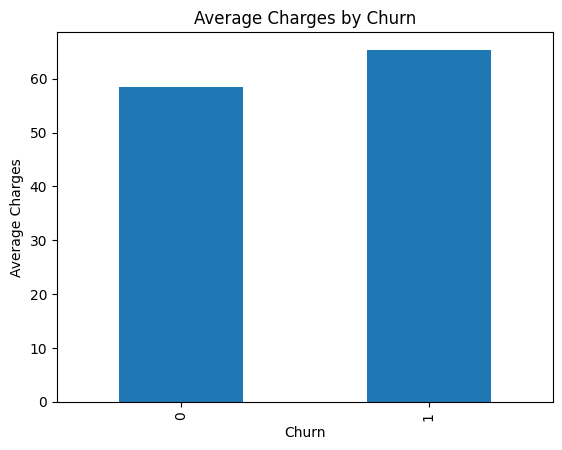

In [102]:
customers.groupby('churn')['total_charges'].mean().plot(kind='bar')

plt.title("Average Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Charges")
plt.show()

In [103]:
pd.crosstab(
    customers['has_international_plan'],
    customers['churn']
)

churn,0,1
has_international_plan,,
0,2664,346
1,186,137


In [104]:
pd.crosstab(
    customers['has_voice_mail_plan'],
    customers['churn']
)

churn,0,1
has_voice_mail_plan,,
0,2008,403
1,842,80


In [105]:
customers.groupby('state')['churn'].mean().sort_values(ascending=False).head(10)

state
NJ    0.264706
CA    0.264706
TX    0.250000
MD    0.242857
SC    0.233333
MI    0.219178
MS    0.215385
NV    0.212121
WA    0.212121
ME    0.209677
Name: churn, dtype: float64

In [106]:
customers.groupby('churn')['rule_based_churn_risk_score'].mean()

churn
0    13.029825
1    31.625259
Name: rule_based_churn_risk_score, dtype: float64

In [107]:
customers[['account_length',
           'total_minutes',
           'total_calls',
           'total_charges',
           'customer_service_calls',
           'rule_based_churn_risk_score']].describe()

,account_length,total_minutes,total_calls,total_charges,customer_service_calls,rule_based_churn_risk_score
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,591.864776,305.137114,59.449754,1.562856,15.724572
std,39.822106,89.954251,34.448164,10.502261,1.315491,13.805752
min,1.000000,284.300000,191.000000,22.930000,0.000000,0.000000
25%,74.000000,531.500000,282.000000,52.380000,1.000000,10.000000
50%,101.000000,593.600000,305.000000,59.470000,1.000000,10.000000
75%,127.000000,652.400000,328.000000,66.480000,2.000000,25.000000
max,243.000000,885.000000,416.000000,96.150000,9.000000,80.000000


In [108]:
customers['rule_based_churn_risk_level'].value_counts()

rule_based_churn_risk_level
low       2970
medium     340
high        23
Name: count, dtype: int64

In [109]:
customers.groupby('rule_based_churn_risk_level')['churn'].mean()

rule_based_churn_risk_level
high      0.652174
low       0.099327
medium    0.508824
Name: churn, dtype: float64

## Data Preprocessing

The dataset is prepared for machine learning by removing unnecessary columns and encoding categorical variables.

In [110]:
df = customers.copy()

In [111]:
df = df.drop(
    [
        'customer_id',
        'split',
        'international_plan',
        'voice_mail_plan',
        'rule_based_churn_risk_score',
        'rule_based_churn_risk_level'
    ],
    axis=1
)

df.head()

,state,account_length,area_code,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn,has_international_plan,has_voice_mail_plan,total_minutes,total_calls,total_charges,avg_charge_per_minute,support_call_rate,high_service_calls,usage_intensity,customer_value_segment
0,KS,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0,0,1,717.2,303,75.56,0.105354,0.007812,0,high_usage,high_value
1,OH,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0,0,1,625.2,332,59.24,0.094754,0.009346,0,medium_usage,medium_value
2,NJ,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0,0,0,539.4,333,62.29,0.115480,0.000000,0,low_usage,medium_value
3,OH,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0,1,0,564.8,255,66.80,0.118272,0.023810,0,medium_usage,high_value
4,OK,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0,1,0,512.0,359,52.09,0.101738,0.040000,0,low_usage,low_value


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account_length          3333 non-null   int64  
 2   area_code               3333 non-null   int64  
 3   number_vmail_messages   3333 non-null   int64  
 4   total_day_minutes       3333 non-null   float64
 5   total_day_calls         3333 non-null   int64  
 6   total_day_charge        3333 non-null   float64
 7   total_eve_minutes       3333 non-null   float64
 8   total_eve_calls         3333 non-null   int64  
 9   total_eve_charge        3333 non-null   float64
 10  total_night_minutes     3333 non-null   float64
 11  total_night_calls       3333 non-null   int64  
 12  total_night_charge      3333 non-null   float64
 13  total_intl_minutes      3333 non-null   float64
 14  total_intl_calls        3333 non-null   

In [113]:
df['state'].nunique()

51

In [114]:
df['usage_intensity'].value_counts()

usage_intensity
high_usage      1133
low_usage       1101
medium_usage    1099
Name: count, dtype: int64

In [115]:
df['customer_value_segment'].value_counts()

customer_value_segment
high_value      1133
medium_value    1100
low_value       1100
Name: count, dtype: int64

In [116]:
df = df.drop('state', axis=1)

In [117]:
df['usage_intensity'] = df['usage_intensity'].map({
    'low_usage': 0,
    'medium_usage': 1,
    'high_usage': 2
})

In [118]:
df['customer_value_segment'] = df['customer_value_segment'].map({
    'low_value': 0,
    'medium_value': 1,
    'high_value': 2
})

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   account_length          3333 non-null   int64  
 1   area_code               3333 non-null   int64  
 2   number_vmail_messages   3333 non-null   int64  
 3   total_day_minutes       3333 non-null   float64
 4   total_day_calls         3333 non-null   int64  
 5   total_day_charge        3333 non-null   float64
 6   total_eve_minutes       3333 non-null   float64
 7   total_eve_calls         3333 non-null   int64  
 8   total_eve_charge        3333 non-null   float64
 9   total_night_minutes     3333 non-null   float64
 10  total_night_calls       3333 non-null   int64  
 11  total_night_charge      3333 non-null   float64
 12  total_intl_minutes      3333 non-null   float64
 13  total_intl_calls        3333 non-null   int64  
 14  total_intl_charge       3333 non-null   

### Preprocessing Summary

- Removed identifiers and leakage-related columns
- Encoded categorical variables
- Dropped state due to high cardinality
- Prepared dataset for modeling

In [120]:
X = df.drop('churn', axis=1)

y = df['churn']

In [121]:
print(X.shape)
print(y.shape)

(3333, 26)
(3333,)


In [122]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [123]:
print(X.shape)
print(y.shape)
print(X_train.shape)
print(X_test.shape)

(3333, 26)
(3333,)
(2666, 26)
(667, 26)


## Logistic Regression

Logistic Regression is used as the baseline classification model.

In [124]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [125]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [126]:
y_pred = lr.predict(X_test_scaled)

In [127]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy:
0.8920539730134932

Confusion Matrix:
[[549  21]
 [ 51  46]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       570
           1       0.69      0.47      0.56        97

    accuracy                           0.89       667
   macro avg       0.80      0.72      0.75       667
weighted avg       0.88      0.89      0.88       667



### Conclusion

The Logistic Regression model achieved 89.2% accuracy but struggled to identify churn customers effectively, achieving only 47% recall.

## Decision Tree Classifier

A Decision Tree model was trained to capture non-linear relationships between customer behavior and churn.

In [128]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [129]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Accuracy:")
print(accuracy_score(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy:
0.9430284857571214

Confusion Matrix:
[[544  26]
 [ 12  85]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       570
           1       0.77      0.88      0.82        97

    accuracy                           0.94       667
   macro avg       0.87      0.92      0.89       667
weighted avg       0.95      0.94      0.94       667



### Conclusion

Decision Tree significantly improved churn detection and achieved a recall of 88%.

## Random Forest Classifier

Random Forest combines multiple decision trees to improve predictive performance and reduce overfitting.

In [130]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [131]:
print("Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy:
0.9790104947526237

Confusion Matrix:
[[570   0]
 [ 14  83]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       570
           1       1.00      0.86      0.92        97

    accuracy                           0.98       667
   macro avg       0.99      0.93      0.96       667
weighted avg       0.98      0.98      0.98       667



## Feature Importance Analysis

Feature importance is used to identify the variables that contribute most to churn prediction.

In [132]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                   Feature  Importance
20           total_charges    0.200840
16  has_international_plan    0.076663
5         total_day_charge    0.072477
18           total_minutes    0.058525
3        total_day_minutes    0.054931
2    number_vmail_messages    0.052351
15  customer_service_calls    0.049371
23      high_service_calls    0.043203
13        total_intl_calls    0.041220
17     has_voice_mail_plan    0.031567


### Top 10 Important Features

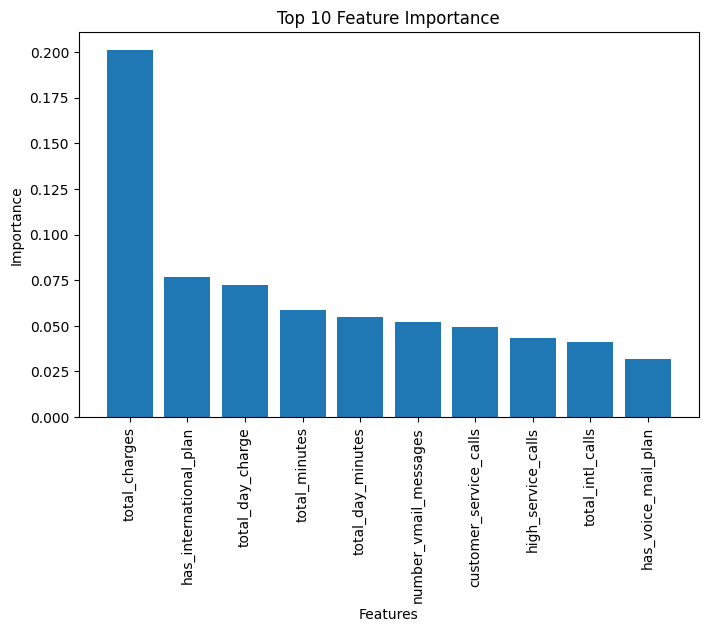

In [133]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.bar(
    top_features['Feature'],
    top_features['Importance']
)

plt.xticks(rotation=90)

plt.title("Top 10 Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

### Key Findings

The most important churn indicators were:

- Total Charges
- International Plan
- Day Charges
- Total Minutes
- Customer Service Calls

These factors can be used by the business to design retention strategies.

## Model Comparison

The performance of all three machine learning models was compared.

In [134]:
results = pd.DataFrame({
    'Model':['Logistic Regression','Decision Tree','Random Forest'],
    'Accuracy':[0.892,0.943,0.979]
})

print(results)

                 Model  Accuracy
0  Logistic Regression     0.892
1        Decision Tree     0.943
2        Random Forest     0.979


In [135]:
customers.to_csv(
    "customer_churn_cleaned.csv",
    index=False
)

# Final Conclusion

Three machine learning models were evaluated for customer churn prediction.

Results:

- Logistic Regression Accuracy: 89.2%
- Decision Tree Accuracy: 94.3%
- Random Forest Accuracy: 97.9%

Random Forest achieved the best overall performance and was selected as the final model.

The analysis revealed that customer charges, international plan subscriptions, and customer service interactions were the strongest indicators of customer churn.